# 🏠 Singapore HDB Resale Price Analysis & Prediction
## Notebook 2 — Exploratory Data Analysis

Questions this EDA answers:

1. What does the **price distribution** look like — and is the market moving?
2. How much do **location** (town), **flat type**, **size**, **floor** and **remaining lease** matter?
3. Which relationships should inform **feature engineering** (Notebook 3)?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook lives in notebooks/ — project root is one level up.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 40)

In [2]:
df = pd.read_csv(ROOT / "data" / "raw" / "hdb_resale_prices_all.csv", parse_dates=["month"])
for col in ["floor_area_sqm", "resale_price", "lease_commence_date"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["year"] = df["month"].dt.year
df["price_per_sqm"] = df["resale_price"] / df["floor_area_sqm"]
df["remaining_lease_years"] = (df["lease_commence_date"] + 99 - df["year"]).clip(lower=0)
print(f"{len(df):,} transactions loaded")

232,614 transactions loaded


## 1. Target distribution

House prices are almost always right-skewed; we check raw and log scale.

count      S$232,614
mean       S$530,555
std        S$189,922
min        S$140,000
25%        S$390,000
50%        S$500,000
75%        S$638,000
max      S$1,728,000


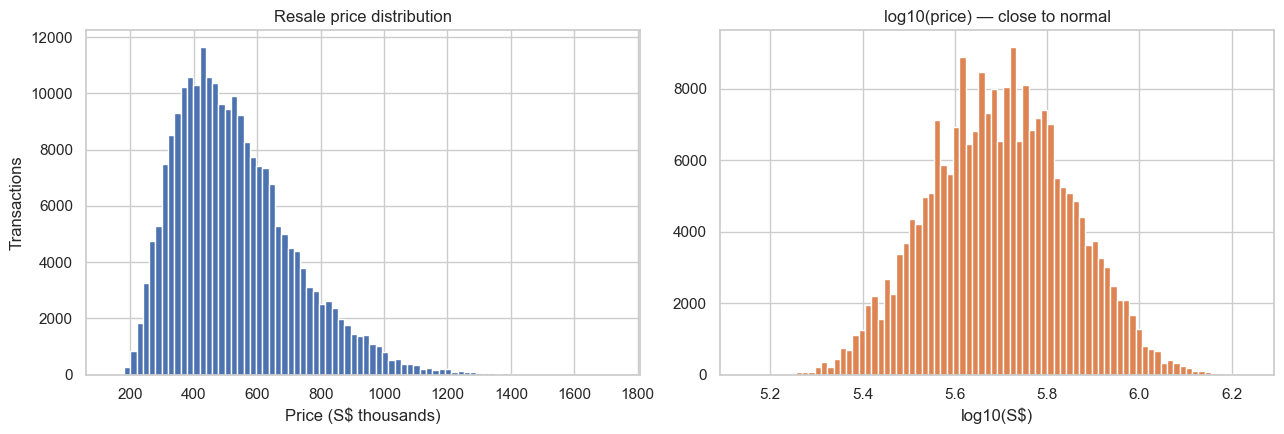

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["resale_price"] / 1000, bins=80, color="#4C72B0")
axes[0].set(title="Resale price distribution", xlabel="Price (S$ thousands)", ylabel="Transactions")
axes[1].hist(np.log10(df["resale_price"]), bins=80, color="#DD8452")
axes[1].set(title="log10(price) — close to normal", xlabel="log10(S$)")
plt.tight_layout()

print(df["resale_price"].describe().apply(lambda v: f"S${v:,.0f}").to_string())

Median ≈ **S$480k** with a long right tail beyond S$1m. The log transform looks Gaussian —
useful to know, although tree-based models (our main models) are scale-invariant so we keep the
raw target for interpretable S$ errors.

## 2. The market is moving — fast

A price model **must** know *when* a flat was sold, not just *what* it is.

Median price 2017-01: S$405,000 → 2026-06: S$605,000  (+49.4%)


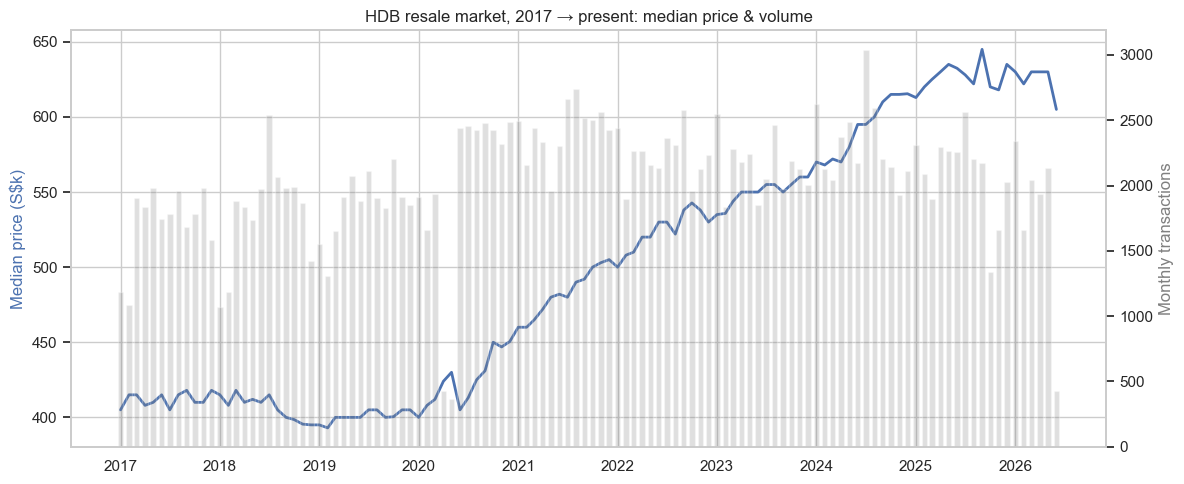

In [4]:
monthly = df.groupby("month")["resale_price"].median()
volume = df.groupby("month").size()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly / 1000, color="#4C72B0", lw=2, label="Median price")
ax1.set_ylabel("Median price (S$k)", color="#4C72B0")
ax1.set_title("HDB resale market, 2017 → present: median price & volume")
ax2 = ax1.twinx()
ax2.bar(volume.index, volume, width=20, alpha=0.25, color="grey", label="Volume")
ax2.set_ylabel("Monthly transactions", color="grey")
ax2.grid(False)
plt.tight_layout()
plt.savefig(FIGURES / "price_trend.png", dpi=150, bbox_inches="tight")

first, last = monthly.iloc[0], monthly.iloc[-1]
print(f"Median price {monthly.index[0]:%Y-%m}: S${first:,.0f} → {monthly.index[-1]:%Y-%m}: S${last:,.0f}  ({(last/first-1):+.1%})")

Three regimes are visible: flat prices 2017–2019, a **COVID-era surge from late 2020**
(construction delays pushed buyers to resale), and continued climb after 2022. Cumulative growth
is roughly +60% — so a *time trend feature* will be one of the most important inputs to any model.

## 3. Location: which towns are expensive?

Comparing raw prices across towns is misleading (different unit-size mix), so we use **price per sqm**.

,median_psm,median_price,n
town,,,
QUEENSTOWN,10000.0,825000.0,939
CENTRAL AREA,8971.0,647500.0,250
BUKIT TIMAH,8883.0,965000.0,77
BUKIT MERAH,8650.0,780000.0,1344
BISHAN,8095.0,846000.0,543
KALLANG/WHAMPOA,7833.0,728000.0,1088
TOA PAYOH,7754.0,780000.0,1480
PUNGGOL,7419.0,671000.0,2221


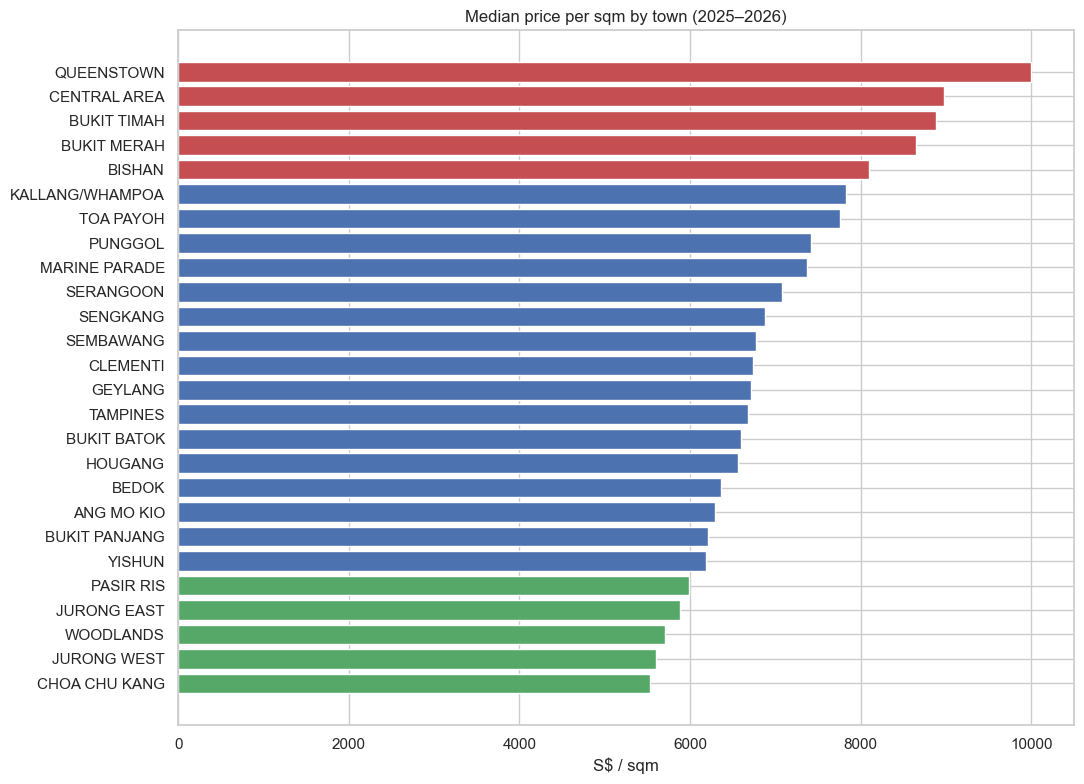

In [5]:
recent = df[df["year"] >= df["year"].max() - 1]  # last ~2 years for a current picture
by_town = recent.groupby("town").agg(
    median_psm=("price_per_sqm", "median"),
    median_price=("resale_price", "median"),
    n=("resale_price", "size"),
).sort_values("median_psm", ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors = ["#C44E52" if i < 5 else ("#55A868" if i >= len(by_town) - 5 else "#4C72B0") for i in range(len(by_town))]
ax.barh(by_town.index[::-1], by_town["median_psm"][::-1], color=colors[::-1])
ax.set(title=f"Median price per sqm by town ({recent['year'].min()}–{recent['year'].max()})", xlabel="S$ / sqm")
plt.tight_layout()
plt.savefig(FIGURES / "town_ranking.png", dpi=150, bbox_inches="tight")
by_town.head(8).round(0)

Central towns (Central Area, Queenstown, Bukit Merah, Kallang/Whampoa) command **~6–7k S$/sqm** while
peripheral towns (Choa Chu Kang, Sembawang, Woodlands) sit near **4–5k**. The gap — over 50% — confirms that
**distance to the city centre** should be engineered as an explicit feature (Notebook 3).

## 4. Flat type & floor area

flat_type
1 ROOM              S$207,500
2 ROOM              S$308,000
3 ROOM              S$360,000
4 ROOM              S$508,000
5 ROOM              S$608,000
EXECUTIVE           S$720,000
MULTI-GENERATION    S$843,500


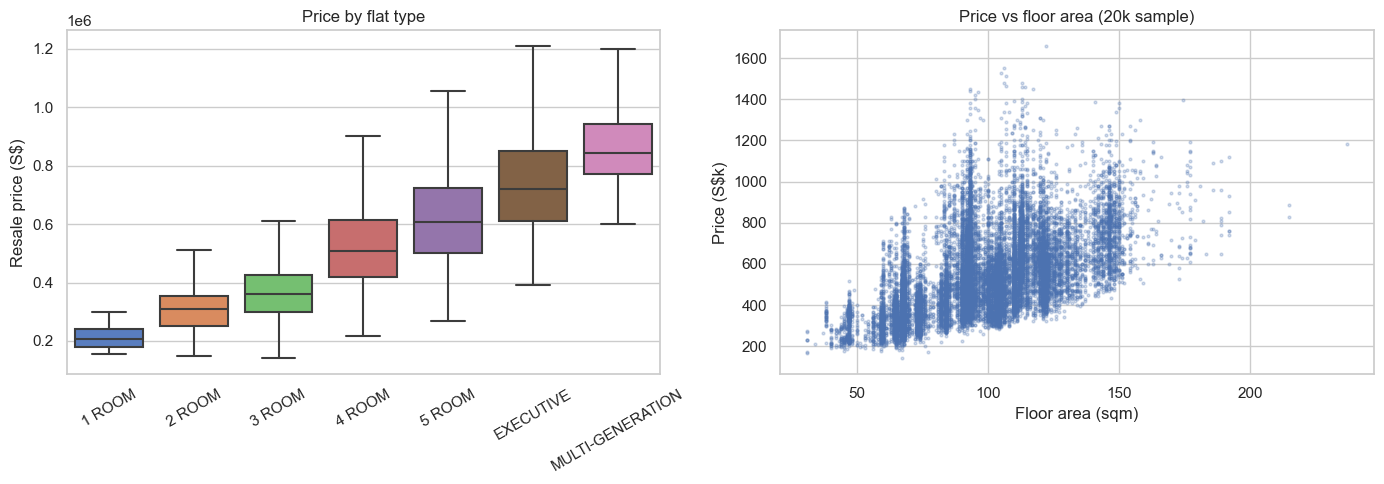

In [6]:
order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="flat_type", y="resale_price", order=order, showfliers=False, ax=axes[0])
axes[0].set(title="Price by flat type", ylabel="Resale price (S$)", xlabel="")
axes[0].tick_params(axis="x", rotation=30)

sample = df.sample(20_000, random_state=42)
axes[1].scatter(sample["floor_area_sqm"], sample["resale_price"] / 1000, s=4, alpha=0.25, color="#4C72B0")
axes[1].set(title="Price vs floor area (20k sample)", xlabel="Floor area (sqm)", ylabel="Price (S$k)")
plt.tight_layout()

print(df.groupby("flat_type")["resale_price"].median().reindex(order).apply(lambda v: f"S${v:,.0f}").to_string())

Price scales strongly with size, but the scatter shows **huge vertical spread at any given area**
(a 100 sqm flat ranges S$400k → S$1m+) — location, floor and lease explain that residual spread.

## 5. Storey: higher floors, higher prices

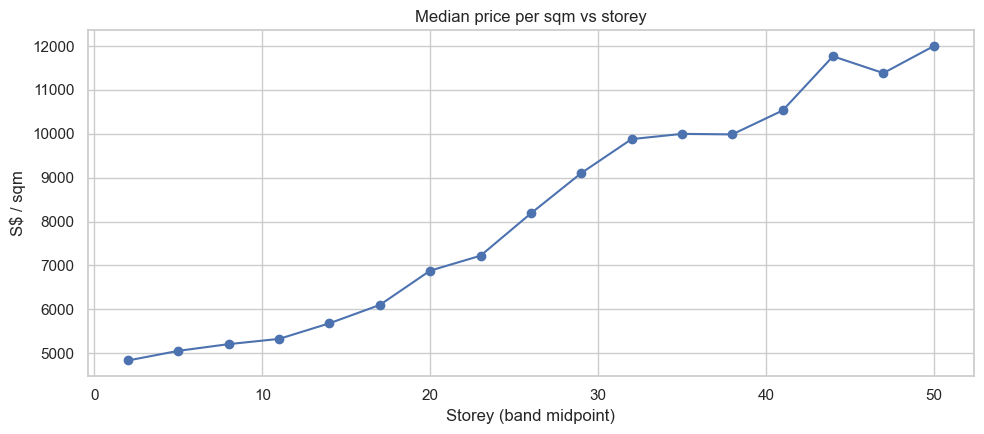

In [7]:
df["storey_mid"] = df["storey_range"].str.extract(r"(\d+)\s+TO\s+(\d+)").astype(float).mean(axis=1)
storey = df.groupby("storey_mid")["price_per_sqm"].median()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(storey.index, storey.values, "o-", color="#4C72B0")
ax.set(title="Median price per sqm vs storey", xlabel="Storey (band midpoint)", ylabel="S$ / sqm")
plt.tight_layout()

A clean monotonic premium: each step up the building adds value, and **floors above ~40 carry a
steep premium** (rare, central, panoramic). The band midpoint (`storey_mid`) is a good numeric encoding.

## 6. Remaining lease — the depreciating asset problem

HDB flats are 99-year leaseholds; value decays toward zero at lease end ("Bala's curve").

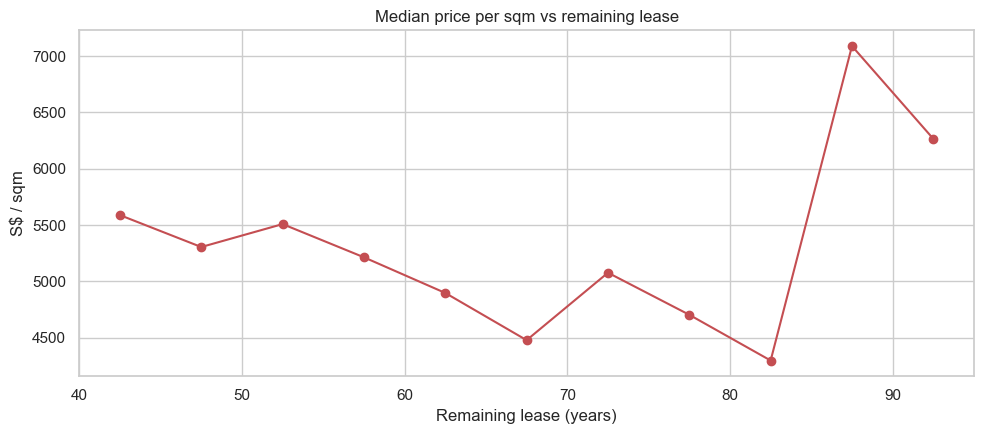

In [8]:
lease_bins = pd.cut(df["remaining_lease_years"], bins=range(40, 100, 5))
lease_curve = df.groupby(lease_bins, observed=True)["price_per_sqm"].median()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot([b.mid for b in lease_curve.index], lease_curve.values, "o-", color="#C44E52")
ax.set(title="Median price per sqm vs remaining lease", xlabel="Remaining lease (years)", ylabel="S$ / sqm")
plt.tight_layout()

The curve rises steadily with remaining lease, then **jumps for ≥90-year leases** — those are flats in
new estates with modern layouts, so part of the jump is a *recency/quality* effect, not pure lease value.
This entanglement is exactly why a multivariate model is needed instead of single-factor rules.

## 7. Correlation overview

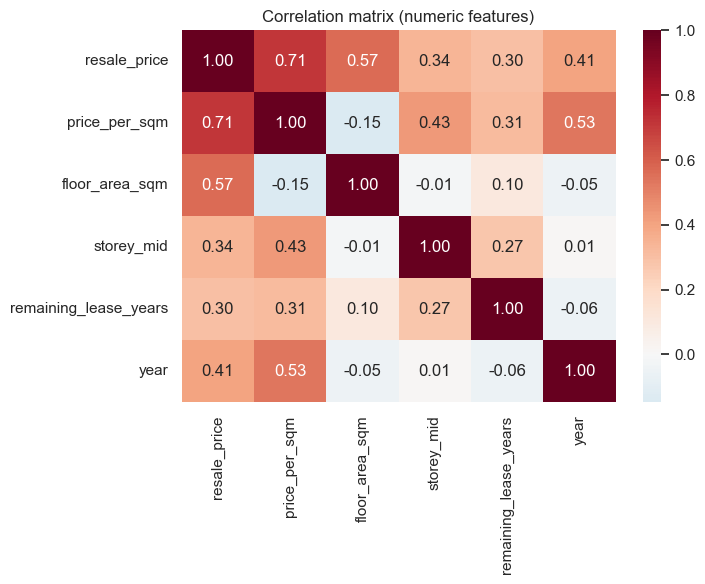

In [9]:
num_cols = ["resale_price", "price_per_sqm", "floor_area_sqm", "storey_mid", "remaining_lease_years", "year"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()

## 8. EDA conclusions → feature plan

| Finding | Feature decision (Notebook 3) |
|---------|------------------------------|
| Strong market-wide trend (+60% since 2017) | Continuous monthly `time_index` |
| Central towns 50%+ pricier per sqm | Geocode addresses → `lat`, `lon`, `dist_cbd_m` |
| Transit access is a classic price driver | `dist_nearest_mrt_m`, bus-stop density |
| Monotonic storey premium | `storey_mid` (band midpoint) |
| Lease decay curve | Exact `remaining_lease` parsed to float years + `flat_age` |
| Flat types are ordered | Ordinal-encode `flat_type` |
| Spread within town remains | Keep `town`, `flat_model` as categoricals for the model |

**Next →** [Notebook 3: Feature Engineering](03_feature_engineering.ipynb)